# captioning benchmark

this notebook is a cell-split version of `benchmark.py` with a few extra visualization helpers.


## imports


In [33]:
import os
import re
import json
import glob
import time
import math
import random
import argparse
from collections import defaultdict
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.transforms import InterpolationMode
import torchvision.transforms as T
from torchvision.models import vit_b_16, ViT_B_16_Weights
from torchvision.datasets import CIFAR10, STL10, VOCDetection, FakeData

## model


In [34]:
def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def list_image_files(folder, exts=("jpg", "jpeg", "png", "webp", "bmp")):
    if folder is None or (not os.path.isdir(folder)):
        return []
    files = []
    for e in exts:
        files.extend(glob.glob(os.path.join(folder, f"**/*.{e}"), recursive=True))
    return sorted(files)

def clean_special_tokens(tokens, stoi):
    # removes <start>/<pad> and stops at <end>
    out = []
    for t in tokens:
        if t == stoi.get("<END>", None):
            break
        if t in (stoi.get("<START>", None), stoi.get("<PAD>", None)):
            continue
        out.append(t)
    return out

def detokenize(token_ids, itos, stoi):
    # converts ids -> string, removing specials
    token_ids = clean_special_tokens(token_ids, stoi)
    words = []
    for i in token_ids:
        w = itos.get(int(i), "<UNK>")
        if w not in ("<START>", "<END>", "<PAD>"):
            words.append(w)
    return " ".join(words)

def load_pil(path):
    return Image.open(path).convert("RGB")

def build_val_transform():
    # matches the training pipeline you used for vit
    return T.Compose([
        T.Resize(256, interpolation=InterpolationMode.BICUBIC),
        T.CenterCrop(224),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])




## loading checkpoints / weights


In [35]:

class ViTTokenEncoder(nn.Module):
    def __init__(self, freeze=True):
        super().__init__()
        weights = ViT_B_16_Weights.IMAGENET1K_V1
        self.vit = vit_b_16(weights=weights)

        if freeze:
            for p in self.vit.parameters():
                p.requires_grad = False

        self.hidden_dim = self.vit.hidden_dim  # 768

    def forward(self, x):
        # returns tokens including cls token: (b, s, d)
        n = x.shape[0]
        x = self.vit._process_input(x)  # (b, num_patches, d)

        cls_token = self.vit.class_token.expand(n, -1, -1)  # (b, 1, d)
        x = torch.cat((cls_token, x), dim=1)                # (b, 1+num_patches, d)

        x = x + self.vit.encoder.pos_embedding
        x = self.vit.encoder.dropout(x)

        x = self.vit.encoder.layers(x)
        x = self.vit.encoder.ln(x)
        return x  # (b, s, d)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)

        div = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        pe = pe.unsqueeze(1)  # (max_len, 1, d_model)

        self.register_buffer("pe", pe)

    def forward(self, x):
        t = x.size(0)
        return x + self.pe[:t]

def causal_mask(t, device):
    m = torch.triu(torch.ones(t, t, device=device), diagonal=1).bool()
    out = torch.zeros(t, t, device=device)
    out[m] = float("-inf")
    return out

class Captioner(nn.Module):
    def __init__(
        self,
        vocab_size,
        pad_id,
        d_model=512,
        nhead=8,
        num_decoder_layers=4,
        dim_feedforward=2048,
        dropout=0.1,
        freeze_vit=True
    ):
        super().__init__()

        self.encoder = ViTTokenEncoder(freeze=freeze_vit)
        enc_dim = self.encoder.hidden_dim  # 768

        self.enc_proj = nn.Linear(enc_dim, d_model)

        self.pad_id = pad_id
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.positional = PositionalEncoding(d_model, max_len=512)
        self.emb_dropout = nn.Dropout(dropout)

        layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=False,
            norm_first=True
        )
        self.decoder = nn.TransformerDecoder(layer, num_layers=num_decoder_layers)

        self.fc_out = nn.Linear(d_model, vocab_size)
        self.fc_out.weight = self.embedding.weight  # weight tying

    def forward(self, images, captions_in):
        # images: (b,3,224,224), captions_in: (b,t)
        b, t = captions_in.shape

        mem = self.encoder(images)             # (b,s,768)
        mem = self.enc_proj(mem)               # (b,s,d)
        mem = mem.transpose(0, 1).contiguous() # (s,b,d)

        tgt = self.embedding(captions_in)      # (b,t,d)
        tgt = tgt.transpose(0, 1).contiguous() # (t,b,d)
        tgt = self.positional(tgt)
        tgt = self.emb_dropout(tgt)

        tgt_mask = causal_mask(t, device=tgt.device)
        tgt_key_padding = (captions_in == self.pad_id)

        out = self.decoder(
            tgt=tgt,
            memory=mem,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_key_padding
        )  # (t,b,d)

        out = out.transpose(0, 1).contiguous() # (b,t,d)
        logits = self.fc_out(out)              # (b,t,v)
        return logits




## coco captions loading


In [36]:

def greedy_decode(model, image_tensor, stoi, itos, time_steps, device, max_len=30):
    model.eval()
    pad_id = stoi["<PAD>"]
    with torch.no_grad():
        img = image_tensor.unsqueeze(0).to(device)
        tokens = [stoi["<START>"]]

        for _ in range(max_len):
            cap_in = torch.tensor(
                [tokens + [pad_id] * (time_steps - len(tokens) + 1)],
                device=device,
                dtype=torch.long
            )[:, :time_steps]

            logits = model(img, cap_in)
            step = len(tokens) - 1
            next_id = int(torch.argmax(logits[0, step], dim=-1).item())

            if next_id == stoi["<END>"] or next_id == pad_id:
                break
            tokens.append(next_id)

        return detokenize(tokens, itos, stoi)

def top_p_decode(model, image_tensor, stoi, itos, time_steps, device, max_len=30, top_p=0.9, temperature=1.0):
    model.eval()
    pad_id = stoi["<PAD>"]
    with torch.no_grad():
        img = image_tensor.unsqueeze(0).to(device)
        tokens = [stoi["<START>"]]

        for _ in range(max_len):
            cap_in = torch.tensor(
                [tokens + [pad_id] * (time_steps - len(tokens) + 1)],
                device=device,
                dtype=torch.long
            )[:, :time_steps]

            logits = model(img, cap_in)
            step = len(tokens) - 1
            logit = logits[0, step] / max(float(temperature), 1e-6)
            probs = F.softmax(logit, dim=-1)

            sorted_probs, sorted_idx = torch.sort(probs, descending=True)
            cumsum = torch.cumsum(sorted_probs, dim=0)
            cutoff = torch.searchsorted(cumsum, float(top_p)).item()
            keep = sorted_idx[:cutoff + 1]
            keep_probs = probs[keep]
            keep_probs = keep_probs / keep_probs.sum()

            next_id = int(keep[torch.multinomial(keep_probs, 1)].item())
            if next_id == stoi["<END>"] or next_id == pad_id:
                break
            tokens.append(next_id)

        return detokenize(tokens, itos, stoi)

def beam_decode(model, image_tensor, stoi, itos, time_steps, vocab_size, device, max_len=30, beam_size=5, alpha=0.7, block_trigrams=True):
    model.eval()
    pad_id = stoi["<PAD>"]
    start_id = stoi["<START>"]
    end_id = stoi["<END>"]

    with torch.no_grad():
        img = image_tensor.unsqueeze(0).to(device)

        beams = [([start_id], 0.0)]
        completed = []

        for _ in range(max_len):
            new_beams = []

            for tokens, logp in beams:
                if tokens[-1] == end_id:
                    completed.append((tokens, logp))
                    continue

                cap_in = torch.tensor(
                    [tokens + [pad_id] * (time_steps - len(tokens) + 1)],
                    device=device,
                    dtype=torch.long
                )[:, :time_steps]

                logits = model(img, cap_in)
                step = len(tokens) - 1
                lp = F.log_softmax(logits[0, step], dim=-1)  # (v,)

                if block_trigrams and len(tokens) >= 3:
                    trigrams = set()
                    for i in range(len(tokens) - 2):
                        trigrams.add((tokens[i], tokens[i+1], tokens[i+2]))

                    prev2 = (tokens[-2], tokens[-1])
                    for v in range(vocab_size):
                        if (prev2[0], prev2[1], v) in trigrams:
                            lp[v] = -1e9

                topk_lp, topk_idx = torch.topk(lp, beam_size)
                for k in range(beam_size):
                    nxt = int(topk_idx[k].item())
                    new_beams.append((tokens + [nxt], logp + float(topk_lp[k].item())))

            if not new_beams:
                break

            def norm_score(item):
                toks, lpv = item
                L = max(1, len(toks) - 1)
                return lpv / (L ** float(alpha))

            new_beams.sort(key=norm_score, reverse=True)
            beams = new_beams[:beam_size]

        completed.extend([b for b in beams if b[0][-1] == end_id])
        if completed:
            best_tokens, _ = max(completed, key=lambda x: x[1] / (max(1, len(x[0]) - 1) ** float(alpha)))
        else:
            best_tokens, _ = max(beams, key=lambda x: x[1] / (max(1, len(x[0]) - 1) ** float(alpha)))

        return detokenize(best_tokens, itos, stoi)




## inference runners


In [37]:
def load_checkpoint(ckpt_path, device):
    ckpt = torch.load(ckpt_path, map_location=device, weights_only = False)
    if not isinstance(ckpt, dict) or "model_state_dict" not in ckpt:
        raise ValueError("this does not look like a .ckpt created by your training code")
    return ckpt

def load_vocab_and_config(meta_json_path):
    with open(meta_json_path, "r") as f:
        meta = json.load(f)
    # meta should contain: config, stoi, itos
    return meta["config"], meta["stoi"], {int(k): v for k, v in meta["itos"].items()}

def build_model_from_config(config, device):
    model = Captioner(
        vocab_size=int(config["vocab_size"]),
        pad_id=int(config["pad_id"]),
        d_model=int(config.get("d_model", 512)),
        nhead=int(config.get("nhead", 8)),
        num_decoder_layers=int(config.get("num_decoder_layers", 4)),
        dim_feedforward=int(config.get("dim_feedforward", 2048)),
        dropout=float(config.get("dropout", 0.1)),
        freeze_vit=bool(config.get("freeze_vit", True)),
    ).to(device)
    return model




## main cli


In [38]:
def random_image_from_images_folder(images_dir, transform):
    files = list_image_files(images_dir)
    if not files:
        return None, None
    path = random.choice(files)
    img = transform(load_pil(path))
    return img, f"images:{path}"

def random_image_from_torchvision(transform, datasets_root, allow_download=False):
    # picks a random dataset and returns a random image tensor
    # captions are not available here (so no metric benchmarking)
    choices = []

    # cifar10
    choices.append(("cifar10", lambda: CIFAR10(root=datasets_root, train=False, download=allow_download)))
    # stl10
    choices.append(("stl10", lambda: STL10(root=datasets_root, split="test", download=allow_download)))
    # voc
    choices.append(("voc", lambda: VOCDetection(root=datasets_root, year="2012", image_set="val", download=allow_download)))

    rng = list(choices)
    random.shuffle(rng)

    for name, ctor in rng:
        try:
            ds = ctor()
            idx = random.randrange(len(ds))
            sample = ds[idx]

            if name == "voc":
                # voc returns (img, target_dict)
                img_pil = sample[0]
            else:
                # cifar/stl return (img, label)
                img_pil = sample[0]

            img = transform(img_pil)
            return img, f"torchvision:{name}[{idx}]"
        except Exception:
            continue

    # fallback: fake data always works, but it's synthetic noise
    ds = FakeData(size=1, image_size=(3, 224, 224), num_classes=10, transform=None)
    img_t, _ = ds[0]
    # fake data already gives a tensor in [0,1], so just normalize
    img = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])(img_t)
    return img, "torchvision:fakedata"




In [39]:
def load_coco_captions(annotations_json_path):
    # returns: dict file_name -> list[str] captions
    with open(annotations_json_path, "r") as f:
        ann = json.load(f)

    # id -> file_name
    id_to_name = {}
    for im in ann["images"]:
        id_to_name[im["id"]] = im["file_name"]

    caps = defaultdict(list)
    for a in ann["annotations"]:
        image_id = a["image_id"]
        caption = a["caption"]
        file_name = id_to_name.get(image_id)
        if file_name is not None:
            caps[file_name].append(caption)

    return caps




In [40]:
# bleu / meteor from nltk (lightweight)
def try_import_nltk():
    try:
        from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
        from nltk.translate.meteor_score import meteor_score
        return corpus_bleu, SmoothingFunction, meteor_score
    except Exception:
        return None, None, None

def tokenize_for_metrics(text):
    # simple tokenization consistent with your project: lowercase + split on spaces
    text = text.lower().strip()
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.split()

def rouge_l_score(ref_tokens, hyp_tokens):
    # computes rouge-l f1 using lcs
    # ref_tokens: list[str], hyp_tokens: list[str]
    n = len(ref_tokens)
    m = len(hyp_tokens)

    # dp lcs
    dp = [[0] * (m + 1) for _ in range(n + 1)]
    for i in range(n):
        for j in range(m):
            if ref_tokens[i] == hyp_tokens[j]:
                dp[i + 1][j + 1] = dp[i][j] + 1
            else:
                dp[i + 1][j + 1] = max(dp[i][j + 1], dp[i + 1][j])

    lcs = dp[n][m]
    if lcs == 0:
        return 0.0

    prec = lcs / max(1, m)
    rec = lcs / max(1, n)
    if prec + rec == 0:
        return 0.0
    return (2 * prec * rec) / (prec + rec)

def compute_metrics(preds, refs_by_key):
    # preds: dict key -> str
    # refs_by_key: dict key -> list[str]

    # tokenize
    keys = [k for k in preds.keys() if k in refs_by_key and len(refs_by_key[k]) > 0]
    if not keys:
        return {}

    # bleu + meteor if nltk exists
    corpus_bleu, SmoothingFunction, meteor_score = try_import_nltk()

    # prepare bleu inputs:
    # nltk expects: list_of_references: list[list[list[str]]] and hypotheses: list[list[str]]
    list_of_references = []
    hypotheses = []

    meteor_vals = []
    rouge_vals = []

    for k in keys:
        hyp = tokenize_for_metrics(preds[k])
        refs = [tokenize_for_metrics(r) for r in refs_by_key[k]]

        hypotheses.append(hyp)
        list_of_references.append(refs)

        # meteor in nltk expects strings or token lists; we pass token lists
        if meteor_score is not None:
            # meteor_score wants list of reference strings or list of ref token lists depending on version
            # safest: join back into strings
            try:
                meteor_vals.append(meteor_score(refs, hyp))
            except TypeError:
                meteor_vals.append(meteor_score([" ".join(r) for r in refs], " ".join(hyp)))

        # rouge-l: take max over refs (common practice)
        rouge_vals.append(max(rouge_l_score(r, hyp) for r in refs) if refs else 0.0)

    out = {}

    if corpus_bleu is not None and SmoothingFunction is not None:
        smooth = SmoothingFunction().method1
        out["bleu_1"] = float(corpus_bleu(list_of_references, hypotheses, weights=(1, 0, 0, 0), smoothing_function=smooth))
        out["bleu_2"] = float(corpus_bleu(list_of_references, hypotheses, weights=(0.5, 0.5, 0, 0), smoothing_function=smooth))
        out["bleu_3"] = float(corpus_bleu(list_of_references, hypotheses, weights=(1/3, 1/3, 1/3, 0), smoothing_function=smooth))
        out["bleu_4"] = float(corpus_bleu(list_of_references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth))
    else:
        out["bleu_1"] = None
        out["bleu_4"] = None

    out["meteor"] = float(np.mean(meteor_vals)) if meteor_vals else None
    out["rouge_l"] = float(np.mean(rouge_vals)) if rouge_vals else None

    return out

def compute_coco_evalcap_metrics(preds, refs_by_key):
    # optional: uses pycocoevalcap for cider (and optionally spice if installed)
    # install: pip install git+https://github.com/salaniz/pycocoevalcap
    try:
        from pycocoevalcap.cider.cider import Cider
    except Exception:
        return {}

    # format expected by evalcap:
    # gts: dict key -> list[{"caption": str}]
    # res: dict key -> [{"caption": str}]
    gts = {}
    res = {}
    for k, hyp in preds.items():
        if k not in refs_by_key:
            continue
        gts[k] = [r for r in refs_by_key[k]]
        res[k] = [hyp]
    out = {}
    cider_scorer = Cider()
    cider_score, _ = cider_scorer.compute_score(gts, res)
    out["cider"] = float(cider_score)

    return out


In [41]:

def generate_caption(model, img_t, stoi, itos, cfg, device, mode, vocab_size):
    time_steps = int(cfg["time_steps"])
    max_len = int(cfg.get("max_decode_len", 30))

    if mode == "greedy":
        return greedy_decode(model, img_t, stoi, itos, time_steps, device, max_len=max_len)

    if mode == "top_p":
        return top_p_decode(
            model, img_t, stoi, itos, time_steps, device,
            max_len=max_len,
            top_p=float(cfg.get("top_p", 0.9)),
            temperature=float(cfg.get("temperature", 1.0))
        )

    # default: beam
    return beam_decode(
        model, img_t, stoi, itos, time_steps, vocab_size, device,
        max_len=max_len,
        beam_size=int(cfg.get("beam_size", 5)),
        alpha=float(cfg.get("alpha", 0.7)),
        block_trigrams=bool(cfg.get("block_trigrams", True))
    )

def run_inference_on_images_folder(model, images_dir, transform, stoi, itos, cfg, device, mode, vocab_size, limit=None):
    files = list_image_files(images_dir)
    if limit is not None:
        files = files[:int(limit)]

    results = []
    for p in files:
        img_t = transform(load_pil(p))
        cap = generate_caption(model, img_t, stoi, itos, cfg, device, mode, vocab_size)
        results.append((p, cap))
    return results

def run_random_inference(model, transform, stoi, itos, cfg, device, mode, vocab_size, datasets_root, allow_download, images_dir=None, n=20):
    results = []
    for _ in range(int(n)):
        # prefer ./images if provided and non-empty, else fallback to torchvision
        img_t, src = random_image_from_images_folder(images_dir, transform) if images_dir else (None, None)
        if img_t is None:
            img_t, src = random_image_from_torchvision(transform, datasets_root, allow_download=allow_download)

        cap = generate_caption(model, img_t, stoi, itos, cfg, device, mode, vocab_size)
        results.append((src, cap))
    return results

def run_coco_benchmark(model, coco_images_dir, coco_ann_json, transform, stoi, itos, cfg, device, mode, vocab_size, n_eval=None, seed=0, print_every=None):
    # n_eval can be none for full evaluation
    refs = load_coco_captions(coco_ann_json)
    keys = [k for k in refs.keys() if os.path.exists(os.path.join(coco_images_dir, k))]
    if not keys:
        raise RuntimeError("no coco images found that match the annotation file names")

    rng = random.Random(int(seed))
    if n_eval is not None:
        keys = rng.sample(keys, k=min(int(n_eval), len(keys)))

    preds = {}
    i = 0
    t0 = time.time()
    for k in keys:
        img_path = os.path.join(coco_images_dir, k)
        img_t = transform(load_pil(img_path))
        preds[k] = generate_caption(model, img_t, stoi, itos, cfg, device, mode, vocab_size)
        i += 1
        if print_every and (i % int(print_every) == 0):
            print(f"processed {i}/{len(keys)} images")
    dt = time.time() - t0

    base = compute_metrics(preds, refs)
    extra = compute_coco_evalcap_metrics(preds, refs)

    # simple throughput stats
    base["num_images"] = len(keys)
    base["sec_total"] = float(dt)
    base["img_per_sec"] = float(len(keys) / max(dt, 1e-9))

    # merge
    base.update(extra)
    return base, preds, refs




In [42]:

def describe_metric_ranges():
    # these are rough coco-style ranges to help you interpret results
    # exact numbers depend heavily on preprocessing, vocab, decoding, and eval setup
    return """
rough interpretation ranges for coco-style captioning (approximate):
- bleu-4:
  - < 0.15: weak / usually undertrained or decoding issues
  - 0.15–0.25: ok baseline
  - 0.25–0.35: solid classic model territory
  - 0.35+: strong (often requires better training / stronger decoder / fine-tuned vision encoder)

- meteor:
  - < 0.20: weak
  - 0.20–0.25: ok baseline
  - 0.25–0.29: solid
  - 0.29+: strong

- rouge-l:
  - < 0.40: weak
  - 0.40–0.50: ok baseline
  - 0.50–0.55: solid
  - 0.55+: strong

- cider (if computed via pycocoevalcap):
  - < 0.60: weak
  - 0.60–0.90: ok baseline
  - 0.90–1.20: solid
  - 1.20+: strong

- spice (if you manage to compute it):
  - < 0.15: weak
  - 0.15–0.20: ok baseline
  - 0.20–0.23: solid
  - 0.23+: strong

notes:
- cider tends to be the most representative "single number" for coco.
- beam search typically increases cider/bleu but can reduce diversity.
- top-p sampling increases diversity but may reduce bleu/cider.
""".strip()




## quick run + visualization
load a model checkpoint, caption a few images, and visualize the results.


### tweakable constants
edit these values to control quick runs, image limits, and coco eval size.


In [43]:
# core
CHECKPOINT_PATH = 'models/vit_transformer_coco_captioner_2026-01-08_best.ckpt'
IMAGES_DIR = './images'
DATASETS_ROOT = './torchvision_data'
MODE = 'beam'  # 'greedy' or 'top_p'
SEED = 0
DEVICE = None  # None -> auto, or 'cpu', 'cuda', 'cuda:0'

# images folder run - - -
IMAGES_LIMIT = None  # set an int to cap images from images_dir

# random dataset run - - - 
ALLOW_DOWNLOAD = False
RANDOM_N = 6  # number of random dataset images to caption

# coco benchmark - - - - 
RUN_COCO = True
COCO_IMAGES_DIR = 'data/coco/val2017'
COCO_ANN_JSON = 'data/coco/annotations/captions_val2017.json'
COCO_EVAL_N = 100  # set an int; None runs full eval
PRINT_EVERY = 10  # progress print interval for coco eval

# decode overrides (optional)
MAX_DECODE_LEN = None
BEAM_SIZE = None
ALPHA = None
BLOCK_TRIGRAMS = None  # None -> leave as model default
TOP_P = None
TEMPERATURE = None


In [44]:
# model loading
checkpoint_path = CHECKPOINT_PATH
images_dir = IMAGES_DIR
mode = MODE
seed = SEED

seed_everything(seed)
device = DEVICE or ('cuda' if torch.cuda.is_available() else 'cpu')

ckpt = load_checkpoint(checkpoint_path, device)
config, stoi, itos = ckpt['config'], ckpt['stoi'], {int(k): v for k, v in ckpt['itos'].items()}
state = ckpt['model_state_dict']

cfg = dict(config)
if MAX_DECODE_LEN is not None:
    cfg['max_decode_len'] = int(MAX_DECODE_LEN)
if BEAM_SIZE is not None:
    cfg['beam_size'] = int(BEAM_SIZE)
if ALPHA is not None:
    cfg['alpha'] = float(ALPHA)
if TOP_P is not None:
    cfg['top_p'] = float(TOP_P)
if TEMPERATURE is not None:
    cfg['temperature'] = float(TEMPERATURE)
if BLOCK_TRIGRAMS is not None:
    cfg['block_trigrams'] = bool(BLOCK_TRIGRAMS)

vocab_size = int(cfg.get('vocab_size', len(stoi)))
model = build_model_from_config(cfg, device)
model.load_state_dict(state, strict=True)
model.eval()

transform = build_val_transform()


In [45]:
# inference
# runs all images in images_dir (cap with images_limit);
# if empty, falls back to random datasets with random_n.
images_results = run_inference_on_images_folder(
    model,
    images_dir,
    transform,
    stoi,
    itos,
    cfg,
    device,
    mode,
    vocab_size,
    limit=IMAGES_LIMIT,
)

if images_results:
    results = images_results
else:
    results = run_random_inference(
        model,
        transform,
        stoi,
        itos,
        cfg,
        device,
        mode,
        vocab_size,
        datasets_root=DATASETS_ROOT,
        allow_download=ALLOW_DOWNLOAD,
        images_dir=images_dir,
        n=RANDOM_N,
    )

results


/home/kennykguo/smol-lm/.venv/lib/python3.13/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


[('./images/deer.jpeg', 'a couple of giraffe standing next to each other'),
 ('./images/fox.jpg', 'a brown and white cat standing next to a tree'),
 ('./images/ski.jpg', 'a person riding skis down a snow covered slope'),
 ('./images/sunset.jpeg', 'a sunset that is sitting on top of a sunset'),
 ('./images/zebra.jpeg', 'a zebra standing on top of a dry grass field')]

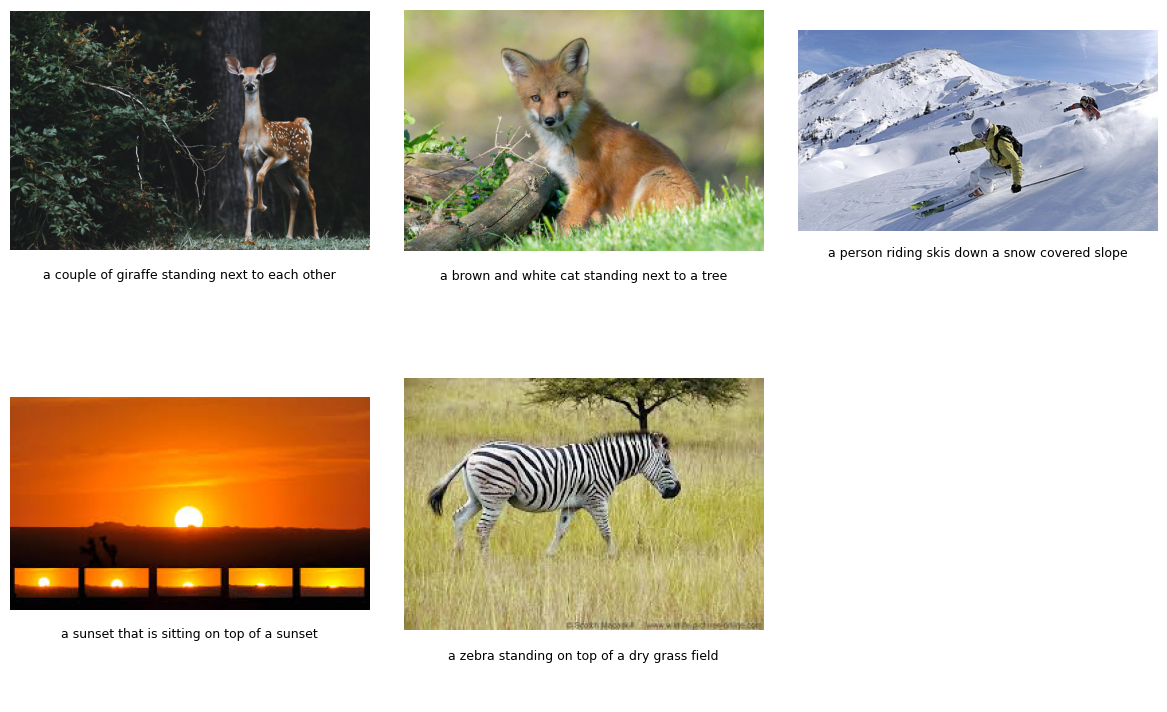

In [46]:
# visualization (image with caption underneath)
try:
    import matplotlib.pyplot as plt
except Exception as e:
    print('matplotlib not available:', e)
    plt = None

if plt is not None:
    n = len(results)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for i, (src, cap) in enumerate(results):
        ax = axes[i]
        if src and isinstance(src, str) and src.startswith('images:'):
            path = src.split(':', 1)[1]
            img = load_pil(path)
        elif src and isinstance(src, str) and os.path.exists(src):
            img = load_pil(src)
        else:
            img = Image.new('RGB', (224, 224), color=(30, 30, 30))
        ax.imshow(img)
        ax.axis('off')
        ax.text(0.5, -0.08, cap, ha='center', va='top', transform=ax.transAxes, wrap=True, fontsize=9)

    for j in range(n, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


## coco benchmark
run metrics on coco val2017 using the constants above.


In [47]:
# coco benchmark
if RUN_COCO:
    if not COCO_IMAGES_DIR or not COCO_ANN_JSON:
        raise ValueError('set COCO_IMAGES_DIR and COCO_ANN_JSON in the constants cell')
    metrics, _, _ = run_coco_benchmark(
        model,
        COCO_IMAGES_DIR,
        COCO_ANN_JSON,
        transform,
        stoi,
        itos,
        cfg,
        device,
        mode,
        vocab_size,
        n_eval=COCO_EVAL_N,
        seed=SEED,
        print_every=PRINT_EVERY,
    )
    metrics


processed 10/100 images
processed 20/100 images
processed 30/100 images
processed 40/100 images
processed 50/100 images
processed 60/100 images
processed 70/100 images
processed 80/100 images
processed 90/100 images
processed 100/100 images


In [48]:
print(metrics)

{'bleu_1': 0.7086776859504132, 'bleu_2': 0.5555337090997698, 'bleu_3': 0.43369580060805774, 'bleu_4': 0.33650546509990636, 'meteor': 0.5016278722390245, 'rouge_l': 0.5461884178264714, 'num_images': 100, 'sec_total': 132.61722779273987, 'img_per_sec': 0.7540498445366727, 'cider': 0.8862072272153467}
